**Asymmetric, zero-mean distribution of probability over mutational effects suffices for zero correction.**

In [1]:
standard_deviation_in_mutational_effect = '0.002' # BS Section 5.3
initial_standard_deviation_in_fitness = \
    standard_deviation_in_mutational_effect

In [2]:
redo_slow_calculations = True
!TZ=America/Chicago date

Sat Dec 15 18:35:56 CST 2018


# Introduction

We investigate numerically [Equation 3.4](https://link.springer.com/article/10.1007/s00285-017-1190-x#Equ10) in the main theorem of Basener and Sanford, which expresses the instantaneous rate of change in mean fitness of the population as the sum of two terms: 

$$\begin{equation*}
   \frac{\text{d}\bar{m}}{\text{d}t}
      = \text{Var}(m) 
       + \underbrace{\frac{1}{\sum_i P_i} \sum_i (B^\text{in}_i - B^\text{out}_i)(m_i - \bar{m})}_\text{correction for mutational effects}.
\end{equation*}$$

The first term on the right-hand side is the variance in fitness of a population with frequency distribution $P$ over the fitness classes $m_i.$ In the absence of mutation, the instantaneous rate of change in mean fitness $\bar{m}$ of the population is equal to the variance $\text{Var}(m)$ of the population in fitness. The second term is a correction for mutational effects, taking into account the differences in rates  $B^\text{in}_i$ of birth **of** organisms in fitness classes and the rates $B^\text{out}_i$ of birth **to** organisms in the classes. If there were no mutation, or if mutation never had an effect on the fitness class of the offspring, then every birth to an organism with fitness $m_i$ would be a birth of an organism with fitness $m_i,$ and it would hold that $B_i^\text{in} - B_i^\text{out} = 0$ for all $i.$ 

The variance is of course non-negative, and is zero only when the population is comprised entirely of organisms in a single fitness class. The correction term can be positive early in the evolutionary process, at least in contrived circumstances. However, as the process converges to the equilibrium distribution of the population over fitness classes, the rate of change in mean fitness goes to zero, and the correction comes to equal the negative variance.

## Overview of the experiment

[<span style='color:red;'>More here</span>]

When mutant offspring range over all fitness classes, as predicated by Basener and Sanford in Sections <a href="https://link.springer.com/article/10.1007/s00285-017-1190-x#Sec16">5.3</a> and <a href="https://link.springer.com/article/10.1007/s00285-017-1190-x#Sec17">5.4</a> of their article, **the equilibrium distribution *does not* depend on the initial distribution of the population.** The purpose in experimenting with different settings of initial variance in fitness is to observe the effect on evolutionary dynamics. There is no effect on the "ultimate fate" of the population. The equilibrium distribution does depend on the fraction of mutations that are beneficial. Unsurprisingly, an effect of reduction in the fraction is reduction of the mean fitness at equilibrium. Surprisingly, we can set the fraction as low as accurate computation with conventional floating-point numbers (<a href="https://en.wikipedia.org/wiki/Double-precision_floating-point_format">binary64</a>) permits&nbsp;&mdash; much smaller than Basener and Sanford indicate is biologically realistic&nbsp;&mdash; and the mean fitness at equilibrium remains positive.

**Note on viewing results.** We recommend opening different versions of this notebook in different windows, and placing the windows side-by-side. It may be helpful, when comparing graphical outputs, to reduce the scale of display in the windows.

In [3]:
%matplotlib notebook
"""
Load the code base.
"""
%run ../../Code/bs.py
"""
Suppress automatic display of graphics generated by Matplotlib. All
graphics are saved to disk, and are displayed by explict commands.
"""
plt.interactive(False)
"""
Define the name of the subdirectory that holds various files associated
with this notebook, and create the directory if it does not exist already.
"""
DIR = 'Asymmetric/'
!if [ ! -d {DIR} ]; then mkdir {DIR}; fi

# Set up the numerical experiment

[<span style='color:red;'>Summarize steps</span>]

## Define fitness classes and related parameters

The fitnesses $m_i$ are spaced uniformly over the interval [-0.1, 0.2], with endpoints included. The spacing of 0.0005 comes from Basener and Sanford (Section 5.4).  We set the upper limit on fitness higher here than in some other experiments, because it is otherwise difficult to see the dynamics of the evolutionary process.

In [4]:
"""
The initial calculations are done in high-precision floating point. We
convert the results to conventional floating point (binary64) later, to
speed calculations.
"""
min_fitness = mp_float('-0.1')
max_fitness = mp_float('0.2')
subinterval_length = mp_float('5e-4')
factors = Factors.construct(min_fitness, max_fitness, subinterval_length)

print('Number of fitness classes        :', factors.n_classes)
print('Length of fitness subintervals   :', factors.delta)
print('Floating-point precision (digits):', mp.dps)

Number of fitness classes        : 601
Length of fitness subintervals   : 0.0005
Floating-point precision (digits): 50


## Define the initial frequency distribution of the population over fitness classes

Discretize a zero-mean Gaussian distribution over fitness. The standard deviation of the continuous distribution is determined by the parameter

&nbsp;&nbsp;&nbsp;&nbsp;`initial_standard_deviation_in_fitness`,

which is defined in the first cell of this notebook. The mean and standard deviation of the discrete distribution generally do not match the parameters of the continuous distribution exactly.

The population is theoretically infinite, but the frequencies of fitness classes are necessarily finite in the computation. Some solvers of the initial value problem give more-accurate results when the initial frequencies are midrange in magnitude, so we scale the initial frequencies by $2^{512}.$ The reason for making the scalar an integer power of 2 is that the operation changes only the exponents, not the mantissas, in the floating-point representation of the frequencies.

In [5]:
std = mp_float(initial_standard_deviation_in_fitness)

"""
Here we do not crop the tails of the initial frequency distribution as BS
do. Also, we do not set frequencies proportional to Gaussian densities at
subinterval centers as they do, but instead obtain the frequencies by
integrating the density function over subintervals.
"""
initial_frequencies = GaussianFrequencies(factors, mean=0, std=std,
                                          crop=np.inf, density=False)
initial_frequencies[:] *= 2.0 ** 512
initial_mean, initial_variance = initial_frequencies.mean_and_variance()


print('Fitness of initial population')
print('    Mean    :', float(initial_mean))
print('    Variance: ', float(initial_variance))
print('    Std dev : ', float(initial_variance ** 0.5))

Fitness of initial population
    Mean    : -7.078914906390867e-53
    Variance:  4.020833333333333e-06
    Std dev :  0.002005201569252661


## Define the discrete distribution of probability over mutational effects

Next we discretize a Gaussian distribution over the possible effects of mutation on fitness of the offspring.

In [6]:
"""
Change from multiprecision to conventional floating point for speed. The
statistics reported above will no longer be precisely correct.
"""
factors.convert(float)
initial_frequencies.convert(float)

mutations = EffectsDistribution(factors)
n = mutations.zero_index
mutations[n-3:n+4] = [ 1, 2, 1, 0, 6, 1, 0]
#                     -3,-2,-1, 0, 1, 2, 3 
mutations.normalize()

print('Mean effect of mutation on fitness     :',
      float(mutations.mean()))
print('Deleterious-to-advantageous ratio      :',
      float(mutations.deleterious_to_advantageous()))
print('Probability of zero mutation effect    :',
      float(mutations.probability_neutral()))
print('Probability of positive mutation effect:',
      float(mutations.probability_advantageous()))

Mean effect of mutation on fitness     : -2.7755575615628914e-20
Deleterious-to-advantageous ratio      : 0.5714285714285715
Probability of zero mutation effect    : 0.0
Probability of positive mutation effect: 0.6363636363636364


## Define the population, and calculate its equilibrium distribution

Our main use of the `Population` object defined in the following cell is to calculate derivatives $\text{d}P_i/\text{d}t$ of the evolutionary process for a given frequency distribution $P.$ The setting `matrix=True` causes the computation to take the form

$$\mathbf{P^\prime} = W \mathbf{P},$$

as expressed in Section 4 of Basener and Sanford. The equilibrium distribution of the evolutionary process is a scalar multiple of the eigenvector of matrix $W$ corresponding to the largest of its eigenvalues (again, see Section 4 of Basener and Sanford).

In [7]:
label = 'IVP solution'
pop = Population(initial_frequencies, mutations, label=label, matrix=True)
initial_mean = float(pop.mean())

In [8]:
%%time
"""
Solve for the eigenvector corresponding to the largest real eigenvector,
using the initial population as the starting point. Then use the real part
of the solution as the starting point for iteration of the power method.
"""
v = pop.equilibrium(v0=pop, npower=5000)
"""
Now repeat, using the result `v` as the starting point.
"""
equilibrium = pop.equilibrium(v0=v, npower=10000)

CPU times: user 14 s, sys: 698 ms, total: 14.7 s
Wall time: 12.4 s


# Verify that variance and correction sum to zero for the equilibrium distribution

As indicated in the introduction, the sum of the variance and the correction term, which is to say, the rate of change in mean fitness of the population according to the main theorem of Basener and Sanford, approaches zero as the evolutionary process converges on the equilibrium distribution. Of course, we should not expect to see exactly zero in a numerical calculation of this kind.

In [9]:
variance, correction = pop.evaluate_theorem(equilibrium)
rate_of_change = variance + correction

print('Evaluation of Equation 3.4 at the equilibrium distribution')
print('    Variance                      : {:+20.17e}'.format(variance))
print('    Correction                    : {:+20.17e}'.format(correction))
print('    Rate of change in mean fitness: {:+20.17e}'.format(rate_of_change))

Evaluation of Equation 3.4 at the equilibrium distribution
    Variance                      : +1.39993810473054703e-05
    Correction                    : -1.39993810473100053e-05
    Rate of change in mean fitness: -4.53501439959952402e-18


**Establish also that the mean fitness is positive for the equilibrium distribution.**

In [10]:
mean, var = mean_and_variance(factors.growth, equilibrium)
print('Mean fitness over the long term       :', mean)
print('Variance in fitness over the long term:', var)

Mean fitness over the long term       : 0.19528562266689126
Variance in fitness over the long term: 1.399938104731241e-05


# Check a prediction of the initial change in mean fitness

Here the sense of *prediction* is that of theoretical prediction of what we will observe in a numerical solution of the differential-equation model of the evolutionary process. That is, we use Equation 3.4 of Basener and Sanford to calculate the instantaneous rate of change in mean fitness at time 0, and make a linear approximation to the amount of change in mean fitness that will occur over a short period of time $x.$ The approximation is our *prediction* of what the mean fitness will be at time $x.$ Then we solve numerically for the frequency distribution at time $x,$ given the distribution at time 0, and *observe* (directly calculate) the change in mean fitness over the time interval $[0, x].$

Note that this section is primarily pedagogical in purpose. The calculations performed at time 0 will be performed throughout the evolutionary process in the next section.

## Calculate the rate of change in mean fitness at time zero according to Equation 3.4

In [11]:
"""
Calculate the initial rate of change in mean fitness according to Eq. 3.4
of Basener and Sanford.
"""
variance, correction = pop.evaluate_theorem(initial_frequencies[:])
rate_of_change = variance + correction

print('Evaluation of Eq. 3.4 at time 0')
print('    Variance            : {:+20.17e}'.format(variance))
print('    Correction          : {:+20.17e}'.format(correction))
print('    Rate of change (sum): {:+20.17e}'.format(rate_of_change))

Evaluation of Eq. 3.4 at time 0
    Variance            : +4.02083333333332547e-06
    Correction          : -2.79256174797902143e-20
    Rate of change (sum): +4.02083333333329752e-06


## Predict the change in mean fitness over the time interval $[0,\, x]$

With rate of change ${\mathrm{d}\bar{m}}/{\mathrm{d}t}$ in mean fitness at time 0, the mean fitness of the population should change by approximately $x \cdot {\mathrm{d}\bar{m}}/{\mathrm{d}t}$ over a short time interval $[0,\, x].$ We set $x := 1/128.$

In [12]:
x = 1/128
"""
Multiply the rate of change in mean fitness at time 0, calculated
according to Eq. 3.4, by the length x of the time interval [0, x] to
approximate the change in mean fitness over the interval.
"""
predicted_change = x * rate_of_change
label = 'Predicted change in mean fitness over [0, 1/{0}] is {1}'
print(label.format(int(1/x), predicted_change))

Predicted change in mean fitness over [0, 1/128] is 3.141276041666639e-08


## Compare the prediction to the observed result of numerical solution

In [13]:
def ivp_solution(derivative, initial_frequencies, times, max_step=1/128):
    """
    Use the Runge-Kutta 4(5) method to solve for frequencies at specified
    `times`, given the frequencies at the first of those times.
    """
    interval = (times[0], times[-1] + max_step)
    result = solve_ivp(derivative, interval, initial_frequencies,
                       method='RK45', t_eval=times, max_step=max_step,
                       rtol=1e-13, atol=1e-11)
    return result.y.T, result

"""
Solve for frequencies at time `x`, given frequencies at time 0, and use 
them to calculate the mean fitness. The solver calls the object `pop` to
obtain derivatives.
"""
frequencies, report = ivp_solution(pop, initial_frequencies, [0, x], 1/1024)
observed_change = float(accurate_mean(frequencies[1], factors.growth)
                        - accurate_mean(frequencies[0], factors.growth))
relative_error = (predicted_change - observed_change) / observed_change

print(report.message)
print('Predicted change:', predicted_change)
print('Observed change :', observed_change)
print('Relative error  :', relative_error)

The solver successfully reached the interval end.
Predicted change: 3.141276041666639e-08
Observed change : 3.1414702442287575e-08
Relative error  : -6.181900416711868e-05


# Compare predictions to observations throughout an evolutionary process

Next we essentially do at 10 thousand times in the evolutionary process what we just did at the initial time 0. We refer to a number obtained by evaluation of Equation 3.4 as a *prediction*, and to a number obtained by direct calculation of the change in mean fitness over a period of 1/128 year as an *observation.* 

## Calculate predictions and observations

In [14]:
%%time

n_years = 100

"""
It is important to set the small time step `dt` to an integer power of 2.
This ensures that there is no roundoff error when `dt` is added to an
integer time, provided that the integer is not too large. Similarly, 
multiplication of the calculated rate of change by `dt` changes only the
exponent, not the mantissa.
"""
dt = 1/64

"""
Set times to 0, 0+dt, 1, 1+dt, ..., n_years, n_years+dt.
"""
times = np.empty(2 * (n_years + 1))
times[0::2] = np.linspace(0, n_years, n_years+1) # set even-indexed times
times[1::2] = times[0::2] + dt                   # set odd-indexed times

"""
Solve for the frequency distribution at each of the times, given the
initial frequency distribution. The solver calls `pop` to obtain
derivatives.
"""
filename = DIR + 'frequencies.pickled.bz2'

if redo_slow_calculations:
    frequencies, report = ivp_solution(pop, pop[:], times, max_step=dt)
    message = report.message
    with bz2.BZ2File(filename, 'wb') as f:
        pickle.dump((frequencies, message), f, -1)
else:
    with bz2.BZ2File(filename, 'rb') as f:
        frequencies, message = pickle.load(f)

print('Report from initial value problem solver')
print('   ', message)
print('    Derivative evaluations:', report.nfev)

"""
Wrap the sequence of even-indexed frequency distributions with an
`Evolution` object, to facilitate animation below.
"""
ev = Evolution(pop)
ev.set_trajectory(frequencies[::2])
ev.years_per_epoch = 1

"""
Predict the differences in mean fitness at odd- and even-indexed times.
The even-indexed distributions are used to calculate the rates of change
according to Eq. 3.4. The calculated rates are multiplied by `dt` to
predict the changes in mean fitness over intervals of duration `dt`.
"""
theorem_values = np.array([pop.evaluate_theorem(P_t) for P_t in frequencies[0::2]])
variances = theorem_values[:, 0]
corrections = theorem_values[:, 1]
rates_of_change = variances + corrections
predictions = dt * rates_of_change

"""
Calculate the actual differences in mean fitness at odd- and even-indexed
times. The first step is to normalize each of the frequency distributions.
"""
frequencies = (frequencies.T / np.sum(frequencies, axis=1)).T
means, _ = mean_and_variance(factors.growth, frequencies)
observations = means[1::2] - means[0::2]

Report from initial value problem solver
    The solver successfully reached the interval end.
    Derivative evaluations: 207572
CPU times: user 49.4 s, sys: 7.81 s, total: 57.2 s
Wall time: 44.7 s


## Display results

The first of the displays, an animation of the evolutionary process, will not appear in static, e.g., PDF, renditions of this notebook.

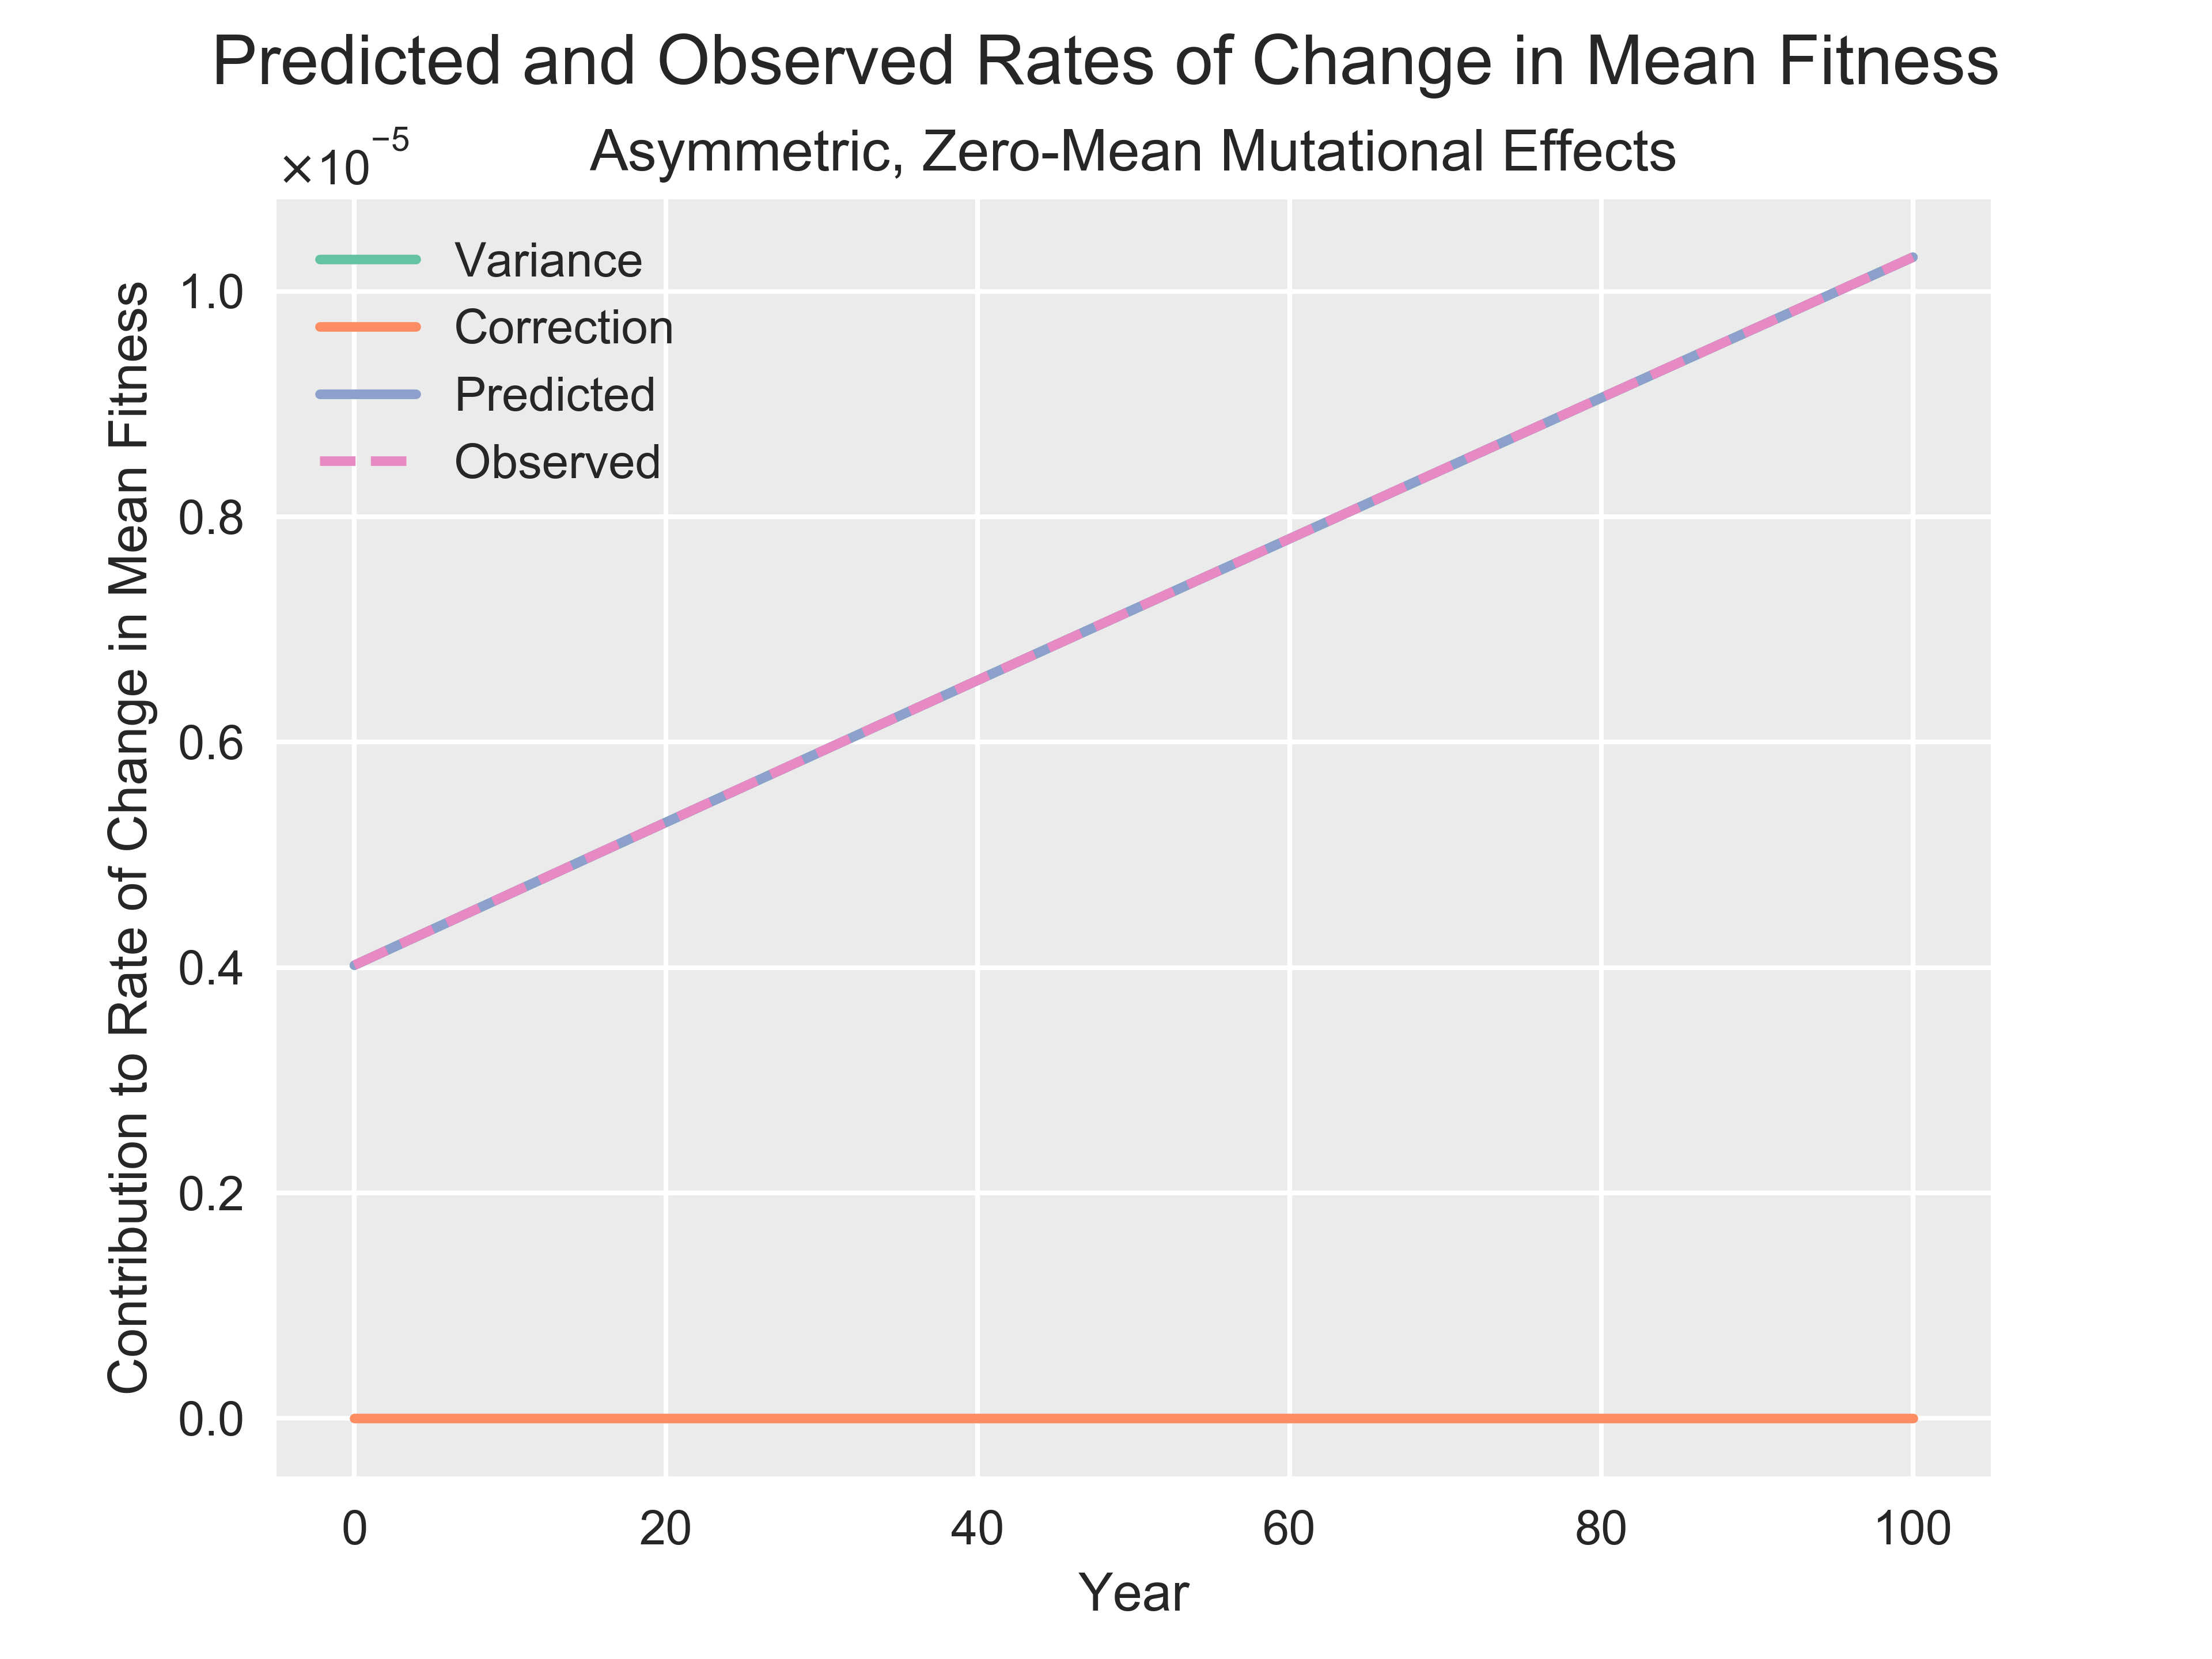

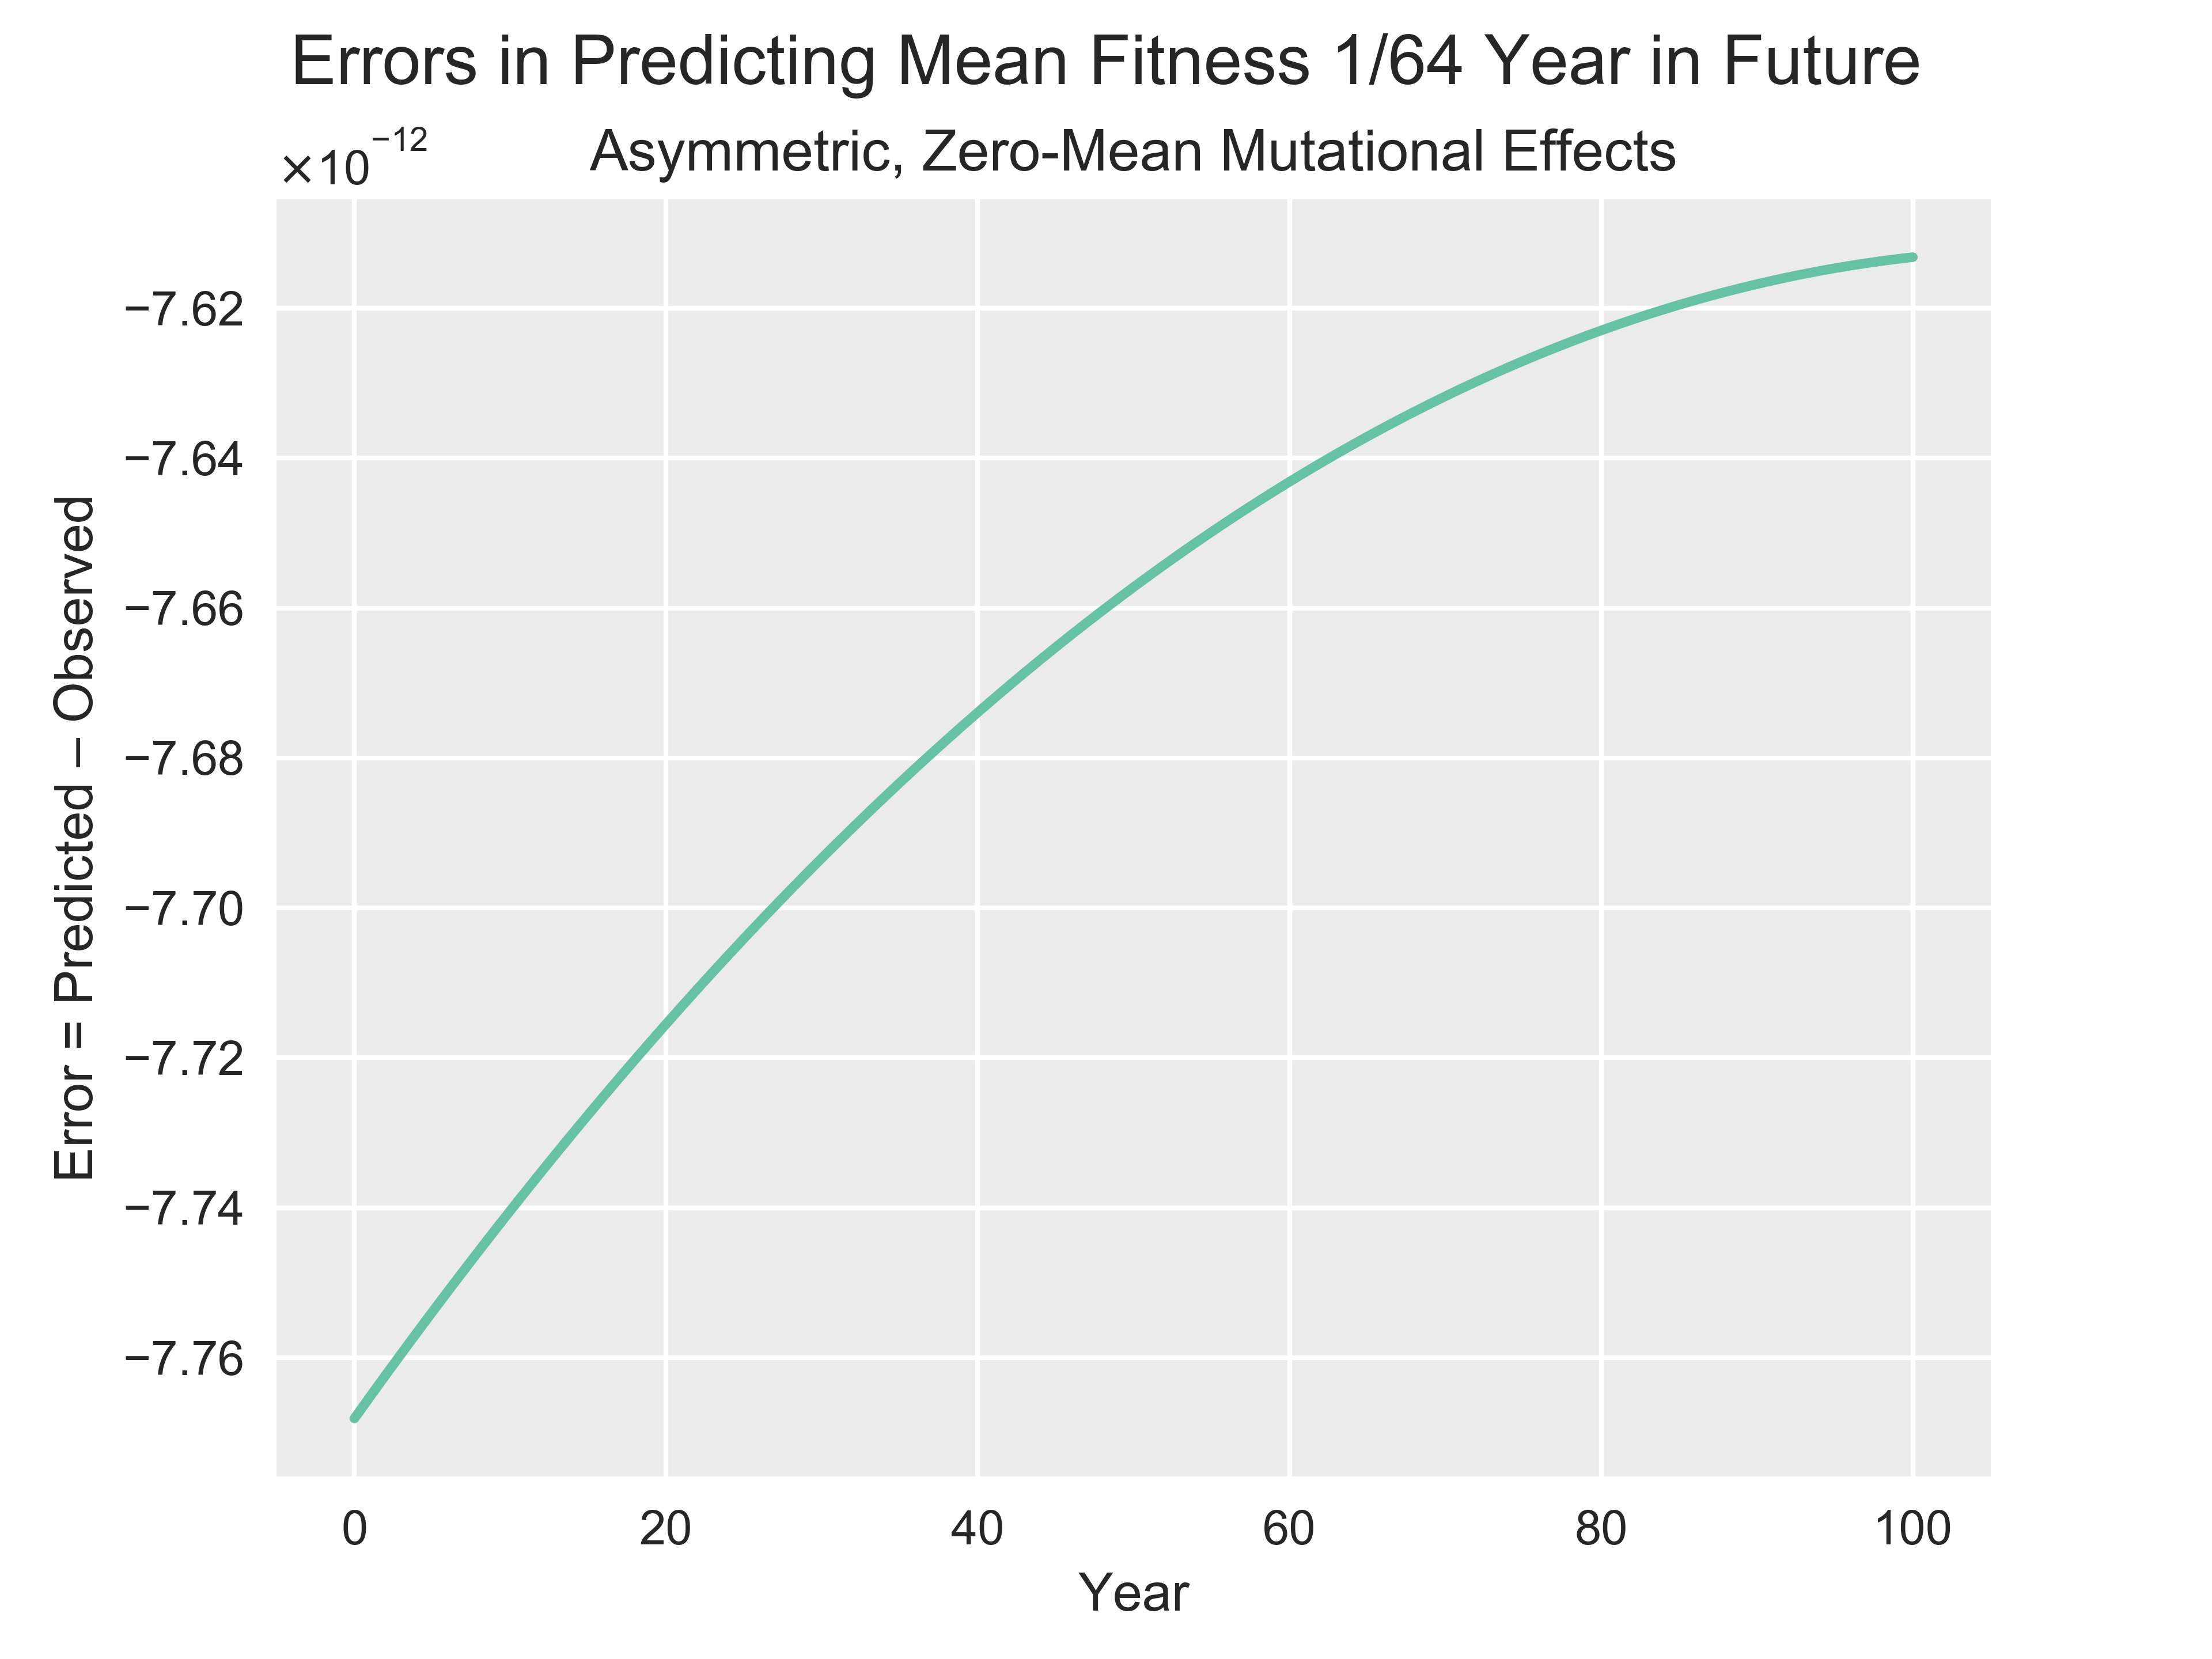

In [15]:
from matplotlib.ticker import ScalarFormatter

subtitle = 'Asymmetric, Zero-Mean Mutational Effects'
subtitle = subtitle.format(standard_deviation_in_mutational_effect)

def animate_evolutionary_process(ev, n_years, n_frames=100, dpi=600):
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=n_frames//10)
    filename = DIR + 'animation.mp4'
    c = Comparison([ev], subtitle=subtitle)
    c.run_until_epoch(n_years)
    a = c.animate(nframes=n_frames, effective=False, dpi=dpi)
    a.save(filename, writer)
    html = """
           <video width="100%" controls autoplay loop>
               <source src={0} type="video/mp4">
           </video>
           """.format(filename)
    display(HTML(html))
    return filename

    
def plot_differences(times, differences):
    fig, ax = plt.subplots()
    ax.plot(times, differences)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-1, 2))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_ylabel('Error = Predicted – Observed')
    ax.set_xlabel('Year')
    title = 'Errors in Predicting Mean Fitness 1/{} Year in Future'
    fig.suptitle(title.format(round(1/dt)))
    ax.set_title(subtitle)
    save_and_display(fig, DIR + 'differences.png')
    return fig, ax

def plot_theorem_values(times, variances, corrections, observed):
    fig, ax = plt.subplots()
    ax.plot(times, variances, label='Variance')
    ax.plot(times, corrections, label='Correction')
    ax.plot(times, variances + corrections, label='Predicted')
    ax.plot(times, observed, label='Observed', ls='--')
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-1, 2))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_xlabel('Year')
    ax.set_ylabel('Contribution to Rate of Change in Mean Fitness')
    ax.legend(loc='best', ncol=1)
    fig.suptitle('Predicted and Observed Rates of Change in Mean Fitness')
    ax.set_title(subtitle)
    save_and_display(fig, DIR + 'theorem_values.png')
    return fig, ax

with warnings.catch_warnings():
    # Ignore warnings in generation of tick marks.
    warnings.simplefilter("ignore")
    animate_evolutionary_process(ev, n_years)

plot_theorem_values(times[0::2], variances, corrections, observations / dt)
plot_differences(times[0::2], (predictions - observations));

# Compare the final frequency distribution to the equilibrium distribution

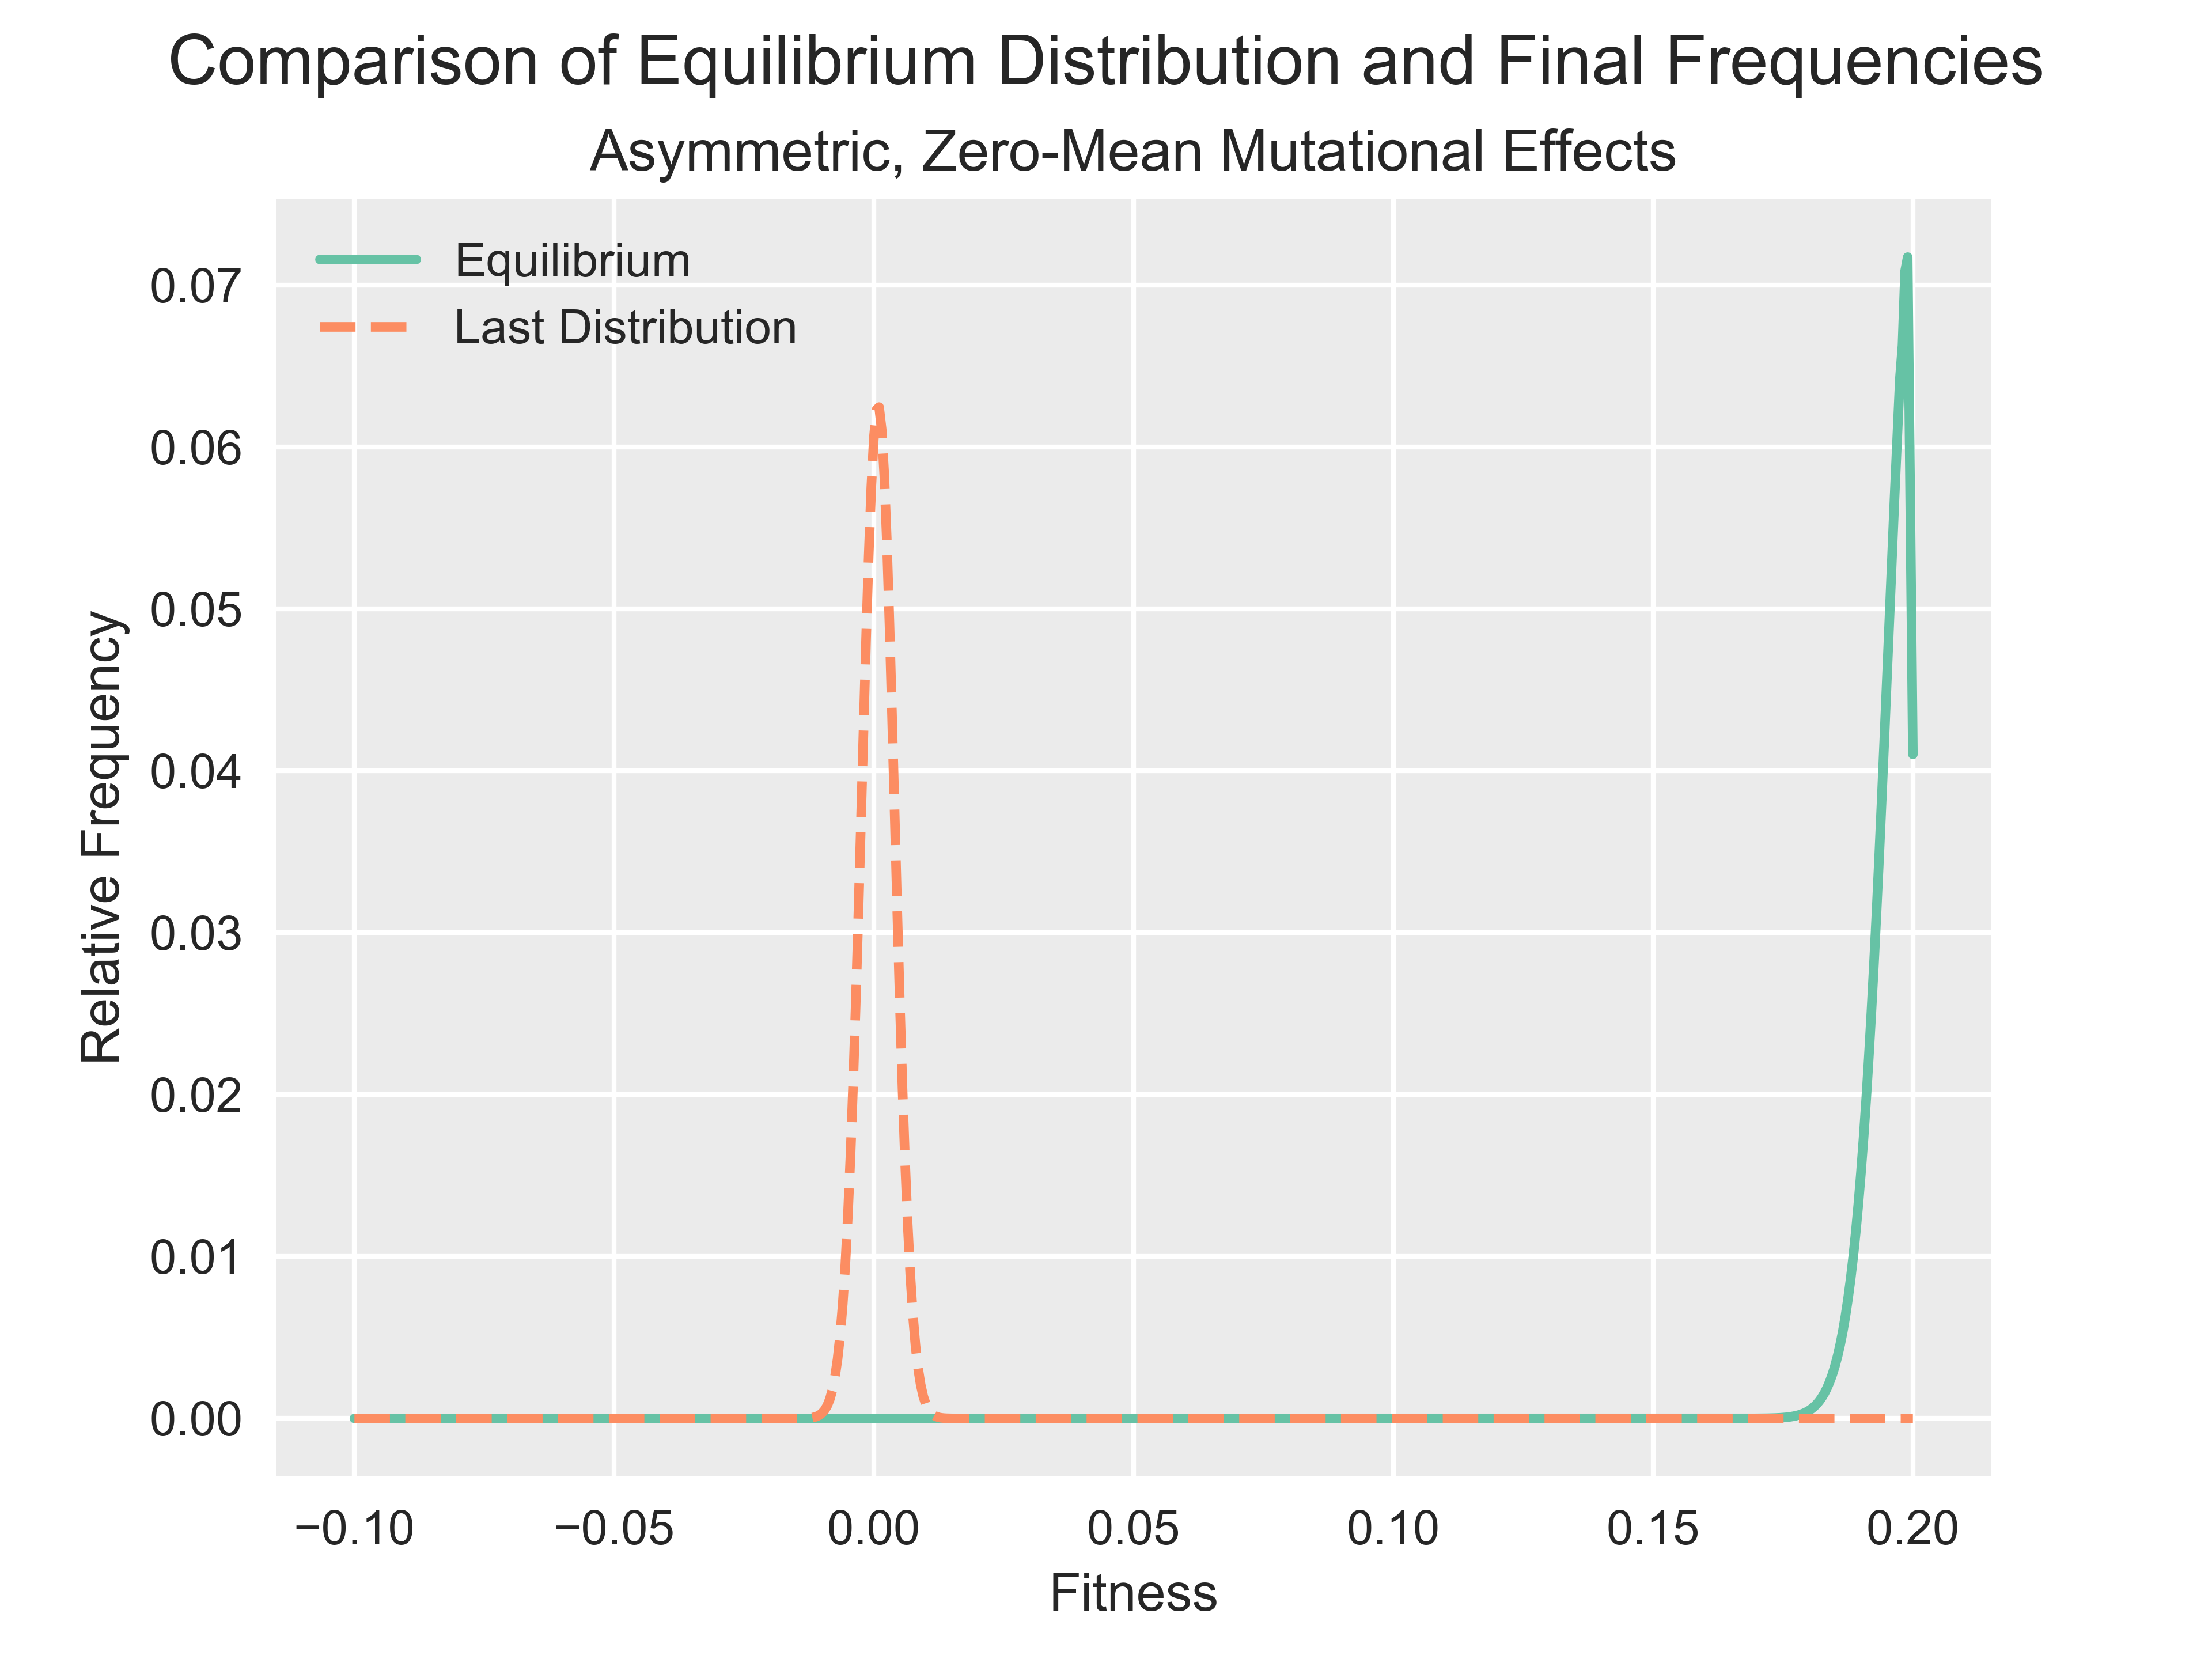

In [16]:
def plot_equilibrium(equilibrium, final_freqs):
    fig, ax = plt.subplots()
    fig.suptitle('Comparison of Equilibrium Distribution and Final Frequencies')
    ax.set_title(subtitle)
    ax.set_xlabel('Fitness')
    ax.set_ylabel('Relative Frequency')
    ax.plot(factors.growth, equilibrium, label='Equilibrium')
    ax.plot(factors.growth, final_freqs, label='Last Distribution', ls='--')
    ax.legend(loc='best')
    save_and_display(fig, DIR + 'equilibrium.png')
    return fig, ax

plot_equilibrium(equilibrium, frequencies[-1]);